# Regression-Implied Relative Valuation - demo

Runs **fully offline** on a synthetic sector panel (no API keys). Set `FMP_API_KEY` and a ticker list for a real sector screen.

Pipeline: sector cross-section -> winsorize 1/99 -> regress EV/EBITDA and P/E on drivers (growth, margin, ROIC, leverage) -> fair multiples -> residual rich/cheap ranking.

In [1]:
%pip install numpy>=1.26 pandas>=2.0 matplotlib>=3.8 statsmodels>=0.14 pytest>=8.0 requests>=2.31 -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Users\pilat\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
# ==== USER INPUTS ====
TICKERS = None            # e.g. ["AAPL", "MSFT", ...] with FMP_API_KEY set; None = synthetic
MULTIPLES = ["ev_ebitda", "pe"]
WINSOR = (0.01, 0.99)     # winsorization quantiles
TOP_N = 5                 # flagged CHEAP/RICH count
SEED = 42
# =====================

In [3]:
import sys
sys.path.insert(0, "../src")
from data_loader import load_sector_panel
from comps import prepare_panel, summary_stats

raw = load_sector_panel(TICKERS, seed=SEED)
panel = prepare_panel(raw, *WINSOR)
print(f"{len(panel)} firms")
summary_stats(panel).round(2)

60 firms


,mean,std,25%,50%,75%
growth,0.07,0.04,0.05,0.08,0.10
ebitda_margin,0.21,0.05,0.18,0.20,0.25
roic,0.12,0.05,0.08,0.11,0.14
leverage,1.79,0.97,1.10,1.64,2.36
ev_ebitda,9.81,3.77,8.06,9.63,11.12
pe,20.27,12.12,16.19,18.88,20.42


## 1. Winsorization - cap the junk before it drives the fit

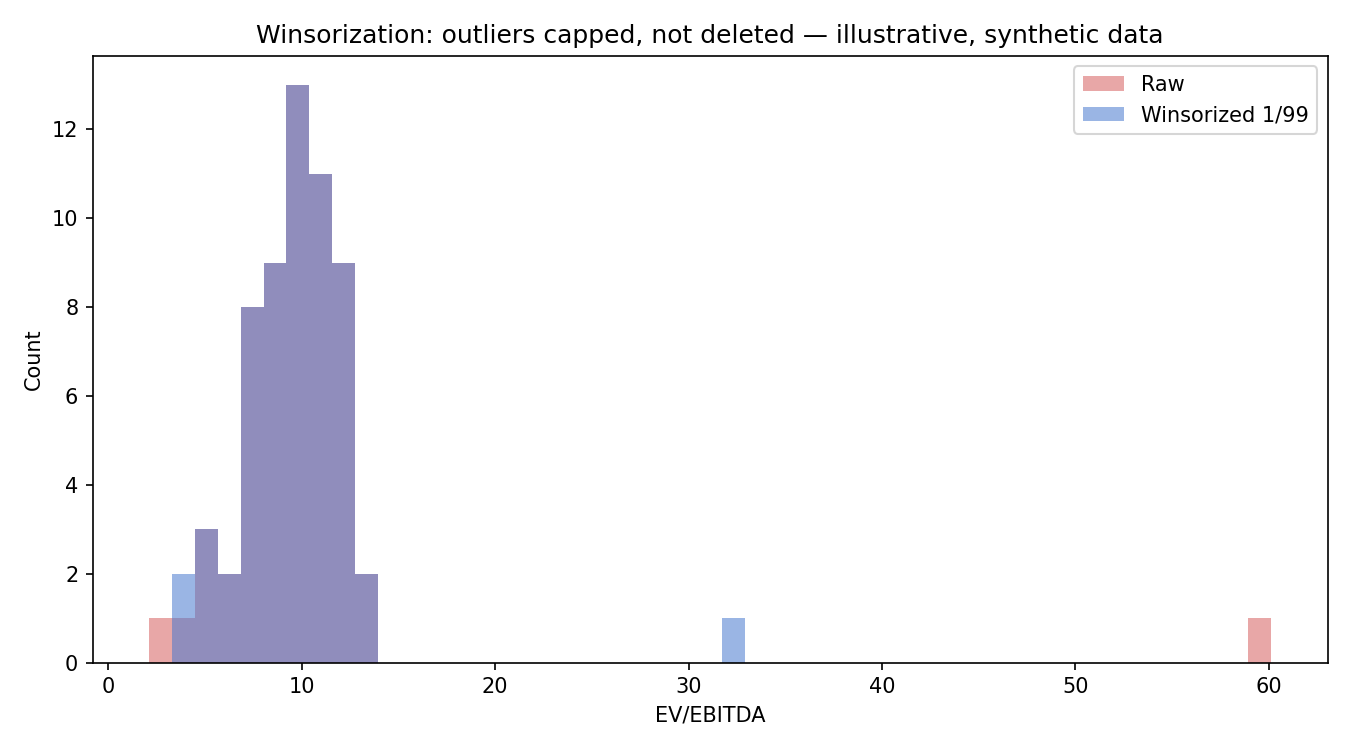

In [4]:
from plots import plot_winsorization_effect
from IPython.display import Image, display
display(Image(str(plot_winsorization_effect(raw["ev_ebitda"].rename("EV/EBITDA"), panel["ev_ebitda"]))))

## 2. Fair-multiple regressions - what *should* each firm trade at?

EV_EBITDA: R² = 0.36
                 coef  t_stat  p_value
const           8.098   7.867    0.000
growth         19.273   2.706    0.007
ebitda_margin  14.352   1.568    0.117
roic            6.696   1.045    0.296
leverage       -1.934  -3.513    0.000 



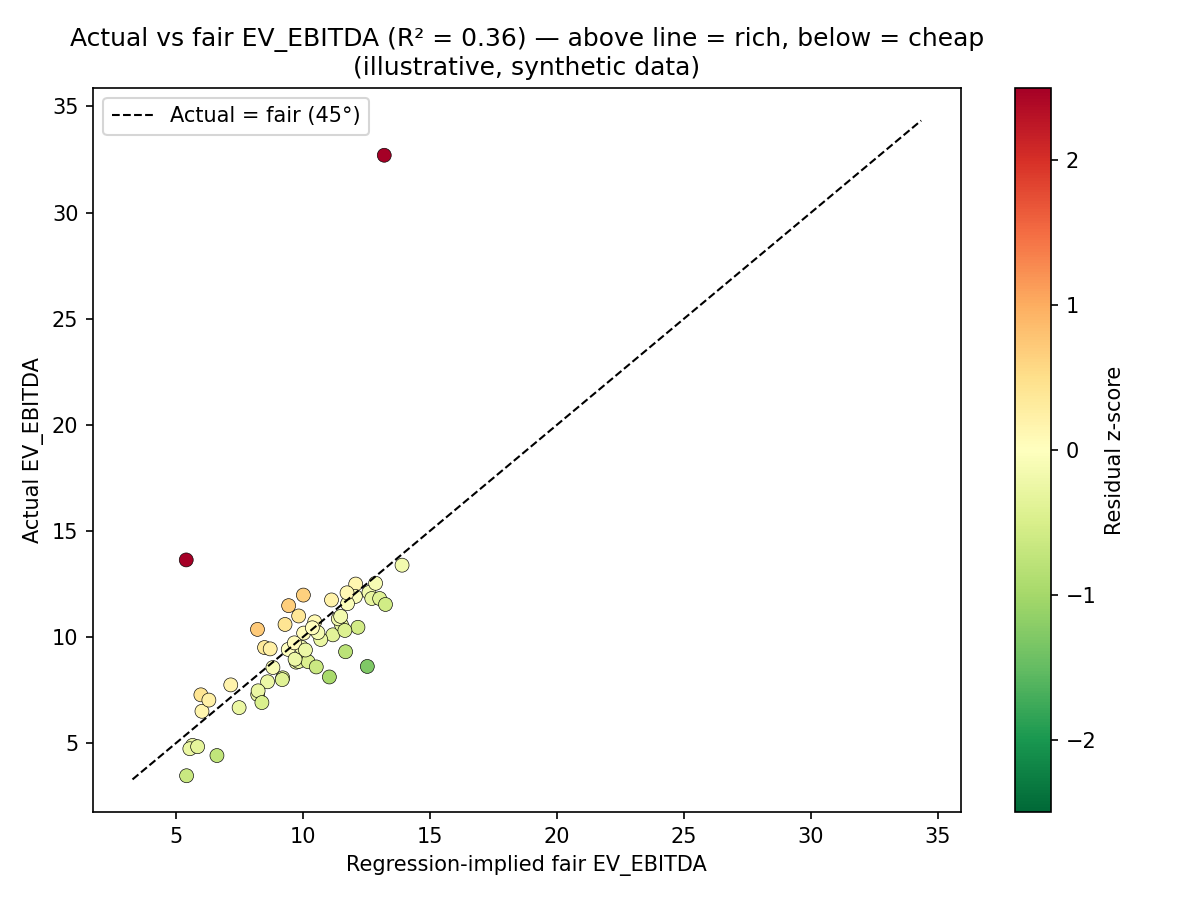

PE: R² = 0.20
                 coef  t_stat  p_value
const          15.657   3.566    0.000
growth         20.565   0.506    0.613
ebitda_margin   0.198   0.013    0.990
roic           87.984   1.683    0.092
leverage       -4.067  -1.548    0.122 



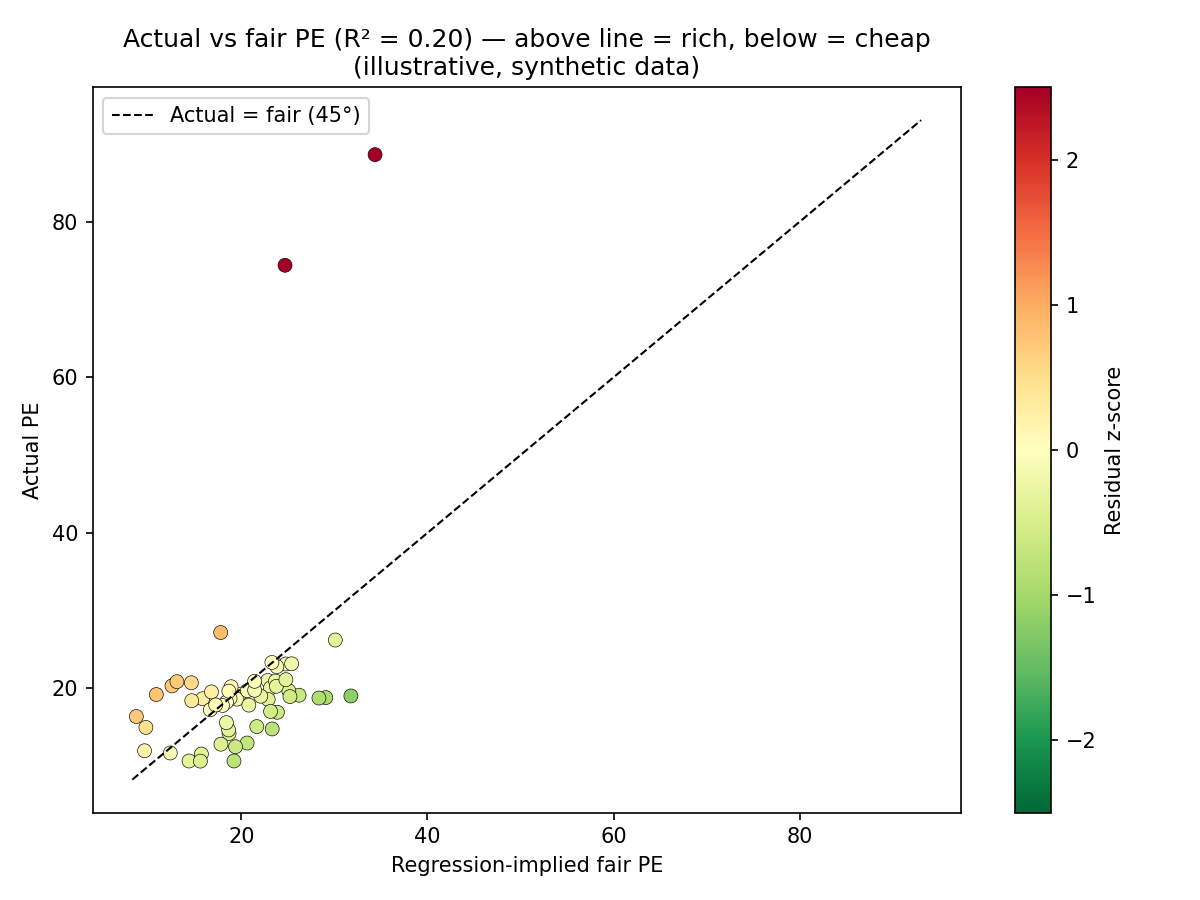

In [5]:
from fair_multiple import fit_fair_multiple
from plots import plot_actual_vs_fair

results = {}
for m in MULTIPLES:
    res = fit_fair_multiple(panel, m)
    results[m] = res
    print(f"{m.upper()}: R² = {res.r_squared:.2f}")
    print(res.coefficients.round(3), "\n")
    display(Image(str(plot_actual_vs_fair(res))))

## 3. Residual ranking - the actual mispricing signal

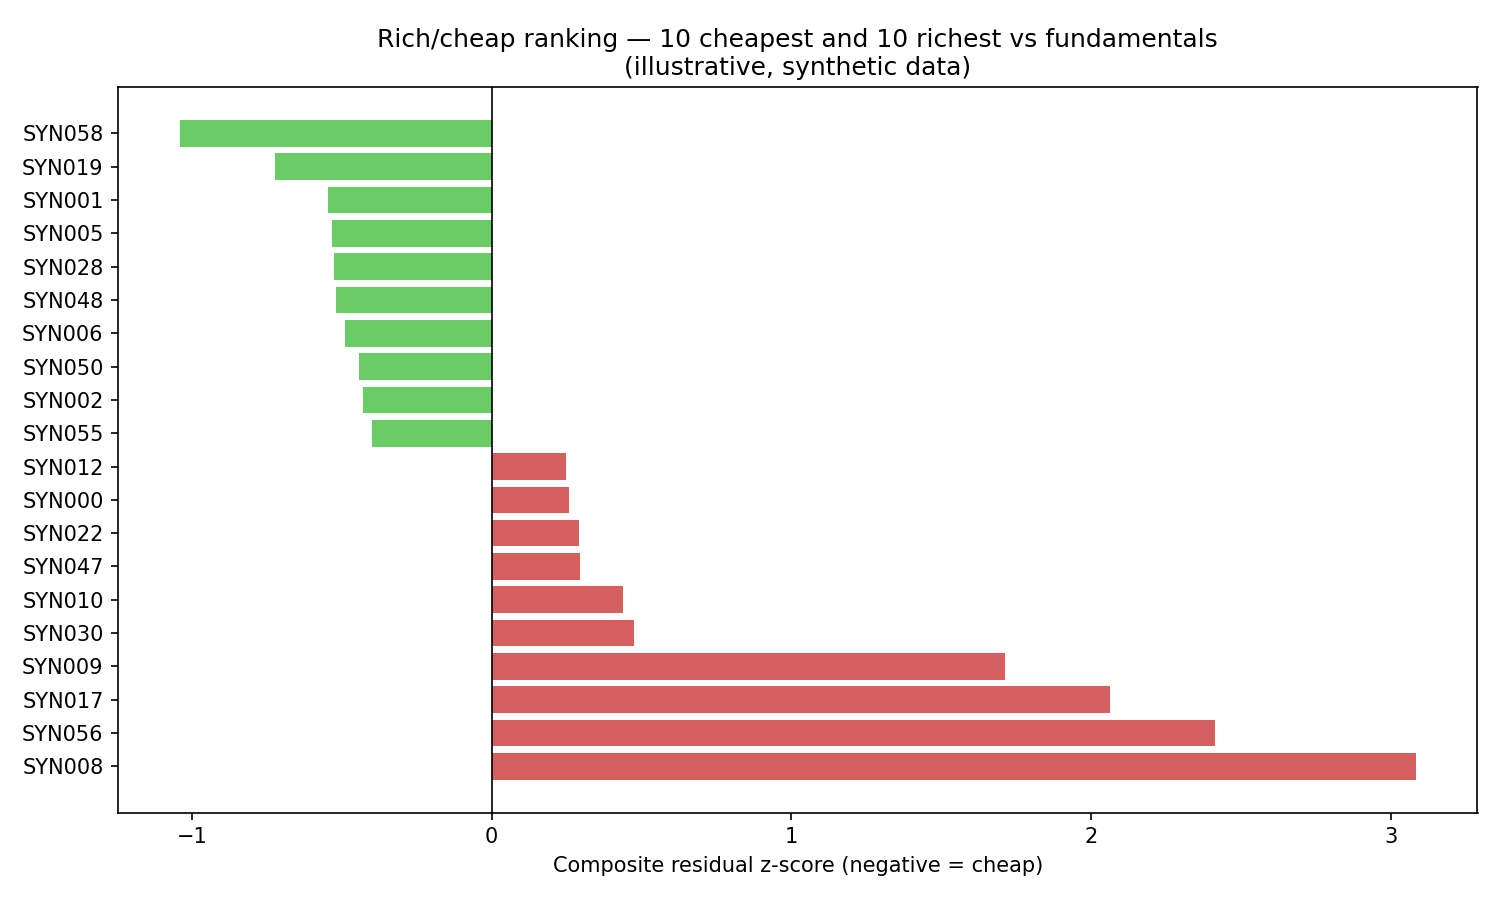

,ev_ebitda,pe,composite_z,flag
ticker,,,,
SYN058,-1.30,-0.79,-1.04,CHEAP
SYN019,-0.27,-1.17,-0.72,CHEAP
SYN001,-0.31,-0.79,-0.55,CHEAP
SYN005,-0.73,-0.34,-0.53,CHEAP
SYN028,-0.11,-0.94,-0.53,CHEAP
SYN030,0.08,0.87,0.47,RICH
SYN009,2.72,0.71,1.71,RICH
SYN017,-0.45,4.58,2.06,RICH
SYN056,-0.17,5.00,2.41,RICH


In [6]:
from fair_multiple import rich_cheap_table
from plots import plot_residual_ranking

ranking = rich_cheap_table(results, top_n=TOP_N)
display(Image(str(plot_residual_ranking(ranking, top_n=10))))
ranking[ranking["flag"] != ""].round(2)